<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/Exercise_04_Regression_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Exercise 4: Predicting Fuel Efficiency with simple linear regression

##### **Objective:**

Create a regression model to predict fuel efficiency (measured in miles per gallon or mpg) using a single feature.

##### **Dataset:**

Auto MPG dataset from the UCI Machine Learning Repository. The dataset contains 398 samples with 8 features, and the
target variable is the fuel efficiency in miles per gallon. (https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data)

1. Import the necessary libraries: pandas, numpy, matplotlib, and scikit-learn.
2. Assign the following column names to the dataset: ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]
3. Perform basic data preprocessing, such as handling missing values.
4. Choose a feature to predict the fuel efficiency (e.g., horsepower or weight).
5. Plot a scatter plot of the chosen feature against the target variable using matplotlib.
6. Create a linear regression model, fit it to the training data, and make predictions on the test (using a reasonable split) data.
7. Evaluate the model's performance on the quality metrics Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).
8. Plot the regression line on the scatter plot.
9. Create a suitable polynomial regression model, fit it to the training data, and make predictions on the test set.
10. Plot the polynomial regression on the scatter plot.
11. Compare both models by evaluating RMSE and MAE.

##### **Hints/reminders:**

- data.columns = \["a", "b", … \] renames columns to ’a’, ’b’, etc.
- pd.to_numeric(data\["a"\] errors='coerce') converts columns a to numeric data or to NaN if conversion is not possible
- data = data.dropna() drops all rows that contain NaN
- Remember np.mean() and np.abs()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

In [ ]:
df = pd.read_csv(url,header=None,delim_whitespace= True)

/tmp/ipython-input-1791613331.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url,header=None,delim_whitespace= True)


In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [ ]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


In [ ]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype='int64')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df.columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin", "car_name"]

In [ ]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='object')

In [ ]:
df['horsepower']= pd.to_numeric(df['horsepower'],errors='coerce')

In [ ]:
df.dropna(inplace = True)

In [ ]:
X = df[['horsepower']]
y = df['mpg']

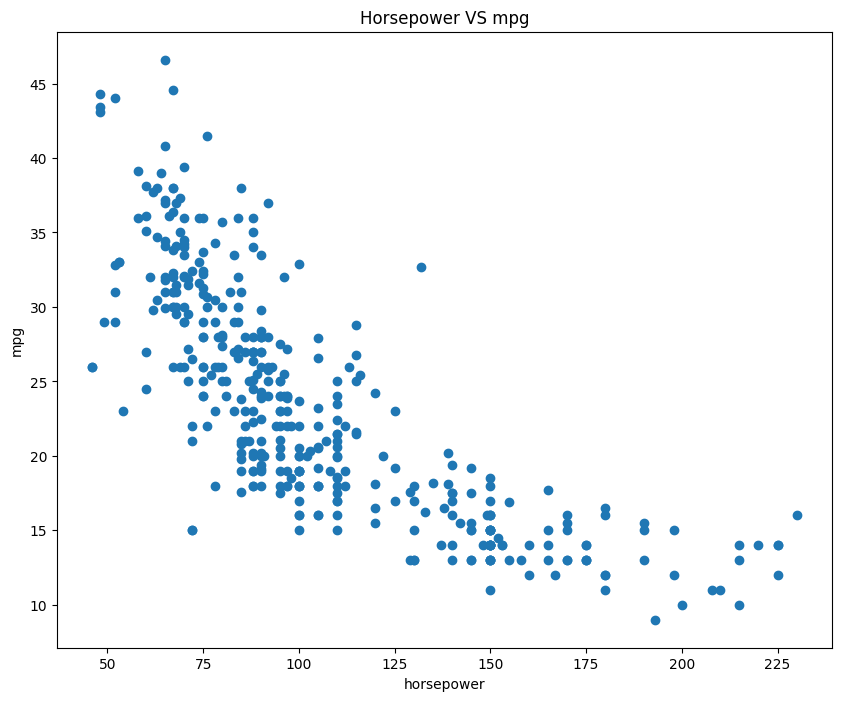

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(X,y)
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title("Horsepower VS mpg")
plt.show()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(313, 1) (79, 1) (313,) (79,)


In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import root_mean_squared_error

In [ ]:
rmse = root_mean_squared_error(y_test,y_pred)
print(f'root Mean Squared Error: {rmse}')

root Mean Squared Error: 4.706722545876633


In [ ]:
mae = mean_absolute_error(y_test,y_pred)
print(f'Mean Absolute Error: {mae}')

Mean Absolute Error: 3.782512710126959


In [ ]:
rs= r2_score(y_test,y_pred)
print(f'R2 Score: {rs}')

R2 Score: 0.5659681822256185


In [ ]:
np_rmse = np.mean(np.abs(y_test-y_pred))
print(f'root Mean Squared Error: {np_rmse}')

root Mean Squared Error: 3.782512710126959


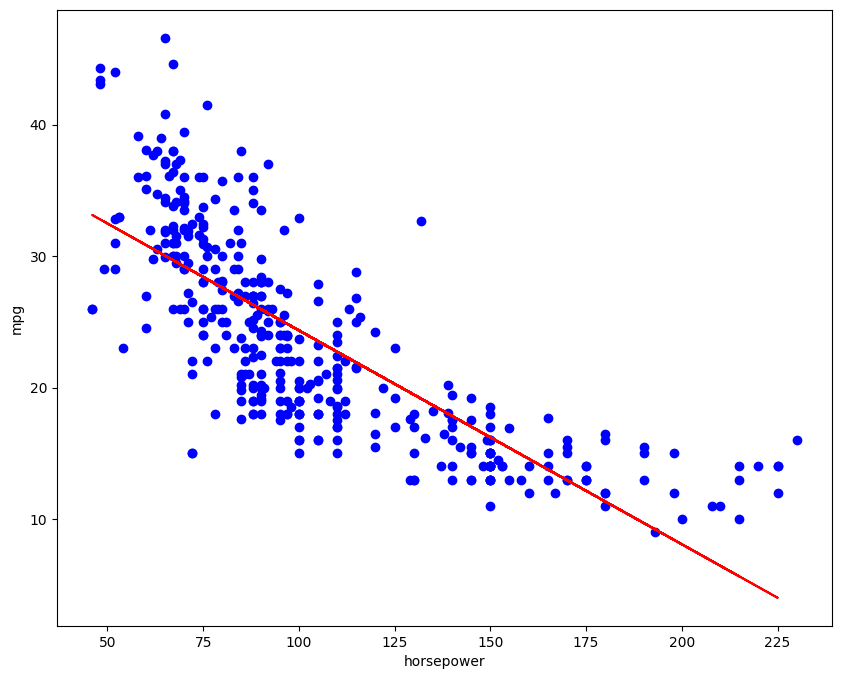

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(X,y,color ='blue')
plt.plot(X_test,model.predict(X_test),color='red')
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.show()

In [ ]:
degree = 2
poly = PolynomialFeatures(degree=degree)

X_poly = pd.DataFrame(poly.fit_transform(X[['horsepower']]),
                      columns=['intercept', 'horsepower', 'horsepower2'])

In [ ]:
X_poly

,intercept,horsepower,horsepower2
0,1.0,130.0,16900.0
1,1.0,165.0,27225.0
2,1.0,150.0,22500.0
3,1.0,150.0,22500.0
4,1.0,140.0,19600.0
...,...,...,...
387,1.0,86.0,7396.0
388,1.0,52.0,2704.0
389,1.0,84.0,7056.0
390,1.0,79.0,6241.0


In [ ]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [ ]:
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

LinearRegression()

In [ ]:
y_pred_poly = model_poly.predict(X_test_poly)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_poly, y_pred_poly))
print(f'Root Mean Squared Error: {rmse:.2f}')

Root Mean Squared Error: 4.29


In [ ]:
sorted_idx = np.argsort(X_test_poly['horsepower'])
X_sorted = X_test_poly['horsepower'].iloc[sorted_idx]
y_sorted = y_pred_poly[sorted_idx]

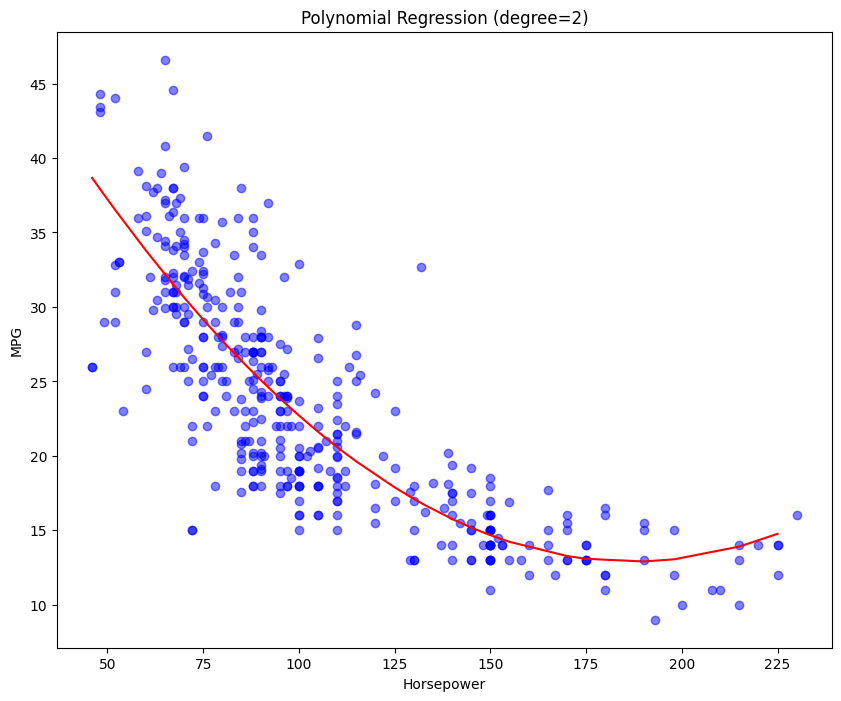

In [ ]:
plt.figure(figsize=(10,8))
plt.scatter(X['horsepower'], y, color='blue', alpha=0.5)
plt.plot(X_sorted, y_sorted, color='red')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Polynomial Regression (degree=2)')
plt.show()

In [ ]:
deg = 3
poly = PolynomialFeatures(degree=deg)
X_poly = poly.fit_transform(X[['horsepower']])


In [ ]:
X_poly_train,X_poly_test,y_poly_train,y_poly_test = train_test_split(X_poly,y,test_size=0.2,random_state=42)

In [ ]:
m = LinearRegression()
m.fit(X_poly_train,y_poly_train)

LinearRegression()

In [ ]:
y_poly_pred = m.predict(X_poly_test)

In [ ]:
rms = root_mean_squared_error(y_poly_test,y_poly_pred)
print(f'Root Mean Squared Error: {rms:.2f}')

Root Mean Squared Error: 4.30


In [ ]:
rsn = r2_score(y_poly_test,y_poly_pred)
print(f'R2 Score: {rsn:.2f}')

R2 Score: 0.64
